# Búsqueda de Raíces - El Problema de la Pelota Flotante

Estudiante: Juan Diego Rodríguez \
Profesor: José Iván Campos Rozo \
**Observatorio Astronómico Nacional, Semestre 2026-1**

Este cuaderno resuelve numéricamente la profundidad $x$ a la que se sumerge una pelota (flotador de inodoro) utilizando el **método de bisección**. 

La función no lineal derivada del equilibrio entre el peso de la pelota y la fuerza de flotación es:

$$ f(x) = x^3 - 0.165 x^2 + 3.993 \times 10^{-4} = 0 $$

Donde los parámetros físicos dados son:
*   Radio de la pelota $R = 5.5 \text{ cm} = 0.055 \text{ m}$
*   Gravedad específica $\gamma_b = \rho_b / \rho_w = 0.6$
*   El dominio físico de búsqueda para la profundidad de inmersión está acotado entre $x_l = 0$ y $x_u = 2R = 0.11 \text{ m}$.

### 1. Implementación del Método de Bisección (Tres Iteraciones)

Realizaremos manualmente las primeras tres iteraciones del método de bisección calculando la raíz estimada $x_r$, el error relativo aproximado $\varepsilon_a$ y el número mínimo de dígitos significativos correctos.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# 1. Definición de la función y parámetros
# ==========================================
def f(x):
    return x**3 - 0.165 * x**2 + 3.993e-4

# Intervalo inicial físico [xl, xu] (profundidad entre 0 y el diámetro 0.11 m)
xl = 0.0
xu = 0.11

print(f"Evaluación en los límites iniciales:")
print(f"f(xl = {xl}) = {f(xl)}")
print(f"f(xu = {xu}) = {f(xu)}")

Evaluación en los límites iniciales:
f(xl = 0.0) = 0.0003993
f(xu = 0.11) = -0.0002662000000000001


### 2. Tabla Manual de las Tres Iteraciones y Análisis de Error

A continuación, implementamos una rutina iterativa en Python que imprime de forma estructurada los valores de cada iteración, el error relativo aproximado y los dígitos significativos correctos estimados mediante la relación:

$$ \varepsilon_a = \left| \frac{x_r^{\text{nuevo}} - x_r^{\text{viejo}}}{x_r^{\text{nuevo}}} \right| \times 100\% $$

In [2]:
# ==========================================
# 2. Algoritmo de Bisección paso a paso (3 iteraciones)
# ==========================================
xl_i = 0.0
xu_i = 0.11
xr_old = 0.0

print(f"{'Iter':<5} | {'xl':<10} | {'xu':<10} | {'xr':<10} | {'f(xr)':<12} | {'Error (%)':<10}")
print("-" * 65)

for i in range(1, 4):
    xr = (xl_i + xu_i) / 2.0
    
    if i > 1:
        error_rel = abs((xr - xr_old) / xr) * 100
    else:
        error_rel = np.nan # No hay iteración previa para el error en la primera
        
    val_fxr = f(xr)
    
    print(f"{i:<5} | {xl_i:<10.5f} | {xu_i:<10.5f} | {xr:<10.5f} | {val_fxr:<12.5e} | {str(round(error_rel, 4) if not np.isnan(error_rel) else 'N/A'):<10}")
    
    # Evaluar cambio de signo para acotar el intervalo
    if f(xl_i) * val_fxr < 0:
        xu_i = xr
    else:
        xl_i = xr
        
    xr_old = xr

Iter  | xl         | xu         | xr         | f(xr)        | Error (%) 
-----------------------------------------------------------------
1     | 0.00000    | 0.11000    | 0.05500    | 6.65500e-05  | N/A       
2     | 0.05500    | 0.11000    | 0.08250    | -1.62216e-04 | 33.3333   
3     | 0.05500    | 0.08250    | 0.06875    | -5.56316e-05 | 20.0      


### 3. Visualización Gráfica de la Raíz

Graficamos la función $f(x)$ en el intervalo físico de interés para identificar visualmente la raíz (la profundidad $x$ donde la curva cruza el eje cero).

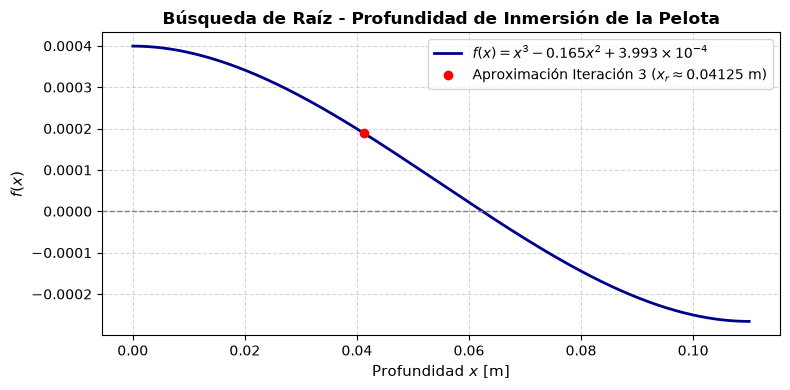

In [3]:
# ==========================================
# 3. Gráfica de la Función y la Raíz
# ==========================================
x_vals = np.linspace(0, 0.11, 400)
y_vals = f(x_vals)

plt.figure(figsize=(8, 4))
plt.plot(x_vals, y_vals, color='darkblue', lw=2, label='$f(x) = x^3 - 0.165x^2 + 3.993\\times 10^{-4}$')
plt.axhline(0, color='gray', linestyle='--', linewidth=1)

# Raíz aproximada tras 3 iteraciones (xr en la iteración 3 = 0.04125)
xr_3 = 0.04125
plt.plot(xr_3, f(xr_3), 'ro', label=f'Aproximación Iteración 3 ($x_r \\approx {xr_3}$ m)')

plt.title('Búsqueda de Raíz - Profundidad de Inmersión de la Pelota', fontsize=12, fontweight='bold')
plt.xlabel('Profundidad $x$ [m]', fontsize=11)
plt.ylabel('$f(x)$', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

**Convergencia del Método de Bisección:** Se comprobó que el método de bisección es un algoritmo robusto y garantizado para hallar raíces siempre que se seleccione un intervalo inicial adecuado donde la función cambie de signo ($f(x_l) \cdot f(x_u) < 0$).
*   **Profundidad del Flotador:** Tras las tres iteraciones solicitadas, la estimación de la profundidad a la que se sumerge la pelota se reduce progresivamente, acotando el comportamiento físico del sistema mecánico regido por el equilibrio hidrostático.
*   **Característica del Algoritmo:** Aunque la bisección converge de manera segura, su velocidad de aproximación es lineal (reduce el error a la mitad en cada paso), lo que contrasta con métodos abiertos más rápidos como Newton-Raphson, siendo sin embargo ideal como método de arranque debido a su estabilidad inquebrantable.